#  Step 1: Install Libraries

In [ ]:
!pip install transformers datasets tensorflow scikit-learn matplotlib torch accelerate -q

#  Step 2: Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
    get_scheduler
)
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


#  Step 3: Load Dataset

In [ ]:
dataset = load_dataset('imdb')

train_texts = list(dataset['train']['text'])
train_labels = list(dataset['train']['label'])
test_texts = list(dataset['test']['text'])
test_labels = list(dataset['test']['label'])

all_texts = train_texts + test_texts
all_labels = train_labels + test_labels

print(f'Total samples: {len(all_texts)}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Total samples: 50000


#  Step 4: Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    all_texts, all_labels,
    test_size=10000,
    train_size=40000,
    random_state=42
)

y_train = np.array(y_train)
y_test  = np.array(y_test)

print(f'Train size: {len(X_train)}')
print(f'Test  size: {len(X_test)}')

Train size: 40000
Test  size: 10000


# =============================================
#  PART A — IMPROVED LSTM MODEL
# =============================================

#  Step 5: Tokenization


In [ ]:
# ✅ FIX: num_words=20000 (was 5000) — captures more vocabulary
# ✅ FIX: maxlen=200 (was 100) — captures more context per review
NUM_WORDS = 20000
MAXLEN    = 200

lstm_tokenizer = Tokenizer(num_words=NUM_WORDS)
lstm_tokenizer.fit_on_texts(X_train)

X_train_seq = lstm_tokenizer.texts_to_sequences(X_train)
X_test_seq  = lstm_tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAXLEN)
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAXLEN)

print(f'X_train_pad shape: {X_train_pad.shape}')  # (40000, 200)
print(f'X_test_pad  shape: {X_test_pad.shape}')   # (10000, 200)

# Quick check — 'fantastic' and 'thrilling' should now be in vocab
vocab = lstm_tokenizer.word_index
for word in ['fantastic', 'thrilling', 'terrible', 'boring']:
    idx = vocab.get(word, 'NOT FOUND')
    status = 'IN VOCAB ✅' if isinstance(idx, int) and idx < NUM_WORDS else 'OUT OF VOCAB ❌'
    print(f'  "{word}" → index {idx} → {status}')

X_train_pad shape: (40000, 200)
X_test_pad  shape: (10000, 200)
  "fantastic" → index 790 → IN VOCAB ✅
  "thrilling" → index 3325 → IN VOCAB ✅
  "terrible" → index 388 → IN VOCAB ✅
  "boring" → index 345 → IN VOCAB ✅


#  Step 6: Build Improved LSTM Model
> **FIX:** Bidirectional LSTM, more Dropout layers, higher embedding dim

In [ ]:
from tensorflow.keras.layers import Bidirectional

lstm_model = Sequential([
    # ✅ FIX: Embedding size matches new num_words=20000
    Embedding(NUM_WORDS, 128, input_length=MAXLEN),

    # ✅ FIX: Bidirectional LSTM — reads text forward AND backward
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(64)),
    Dropout(0.5),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    loss      = 'binary_crossentropy',
    optimizer = 'adam',
    metrics   = ['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#  Step 7: Train Improved LSTM (5 Epochs)
> **FIX:** Added EarlyStopping & ReduceLROnPlateau callbacks

In [ ]:
# ✅ FIX: EarlyStopping — stops training if val_loss stops improving
early_stop = EarlyStopping(
    monitor   = 'val_loss',
    patience  = 2,
    restore_best_weights = True
)

# ✅ FIX: Reduce LR when stuck — helps model converge better
reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,
    patience = 1,
    verbose  = 1
)

history = lstm_model.fit(
    X_train_pad, y_train,
    epochs           = 5,
    batch_size       = 64,
    validation_split = 0.1,
    callbacks        = [early_stop, reduce_lr]
)

Epoch 1/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.8026 - loss: 0.4272 - val_accuracy: 0.8755 - val_loss: 0.3065 - learning_rate: 0.0010
Epoch 2/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9076 - loss: 0.2435
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
563/563 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9013 - loss: 0.2590 - val_accuracy: 0.8470 - val_loss: 0.3632 - learning_rate: 0.0010
Epoch 3/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.9449 - loss: 0.1558 - val_accuracy: 0.8827 - val_loss: 0.3013 - learning_rate: 5.0000e-04
Epoch 4/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9713 - loss: 0.0918
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
563/563 ━━━━━━━━━━━━━━━━━━━━ 25s 44ms/step - accuracy: 0.9681 - loss: 0.0983 - val_accuracy: 0.8808 - val_loss: 0.3826 - learning_rate: 5.0000e-04
Epoch 5/5
563/563 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.9817 - los

#  Step 8: Evaluate LSTM

In [ ]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test_pad, y_test)
print(f'LSTM Test Accuracy : {lstm_acc:.4f}')
print(f'LSTM Test Loss     : {lstm_loss:.4f}')

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - accuracy: 0.8799 - loss: 0.3186
LSTM Test Accuracy : 0.8799
LSTM Test Loss     : 0.3186


#  Step 9: Plot LSTM Training History

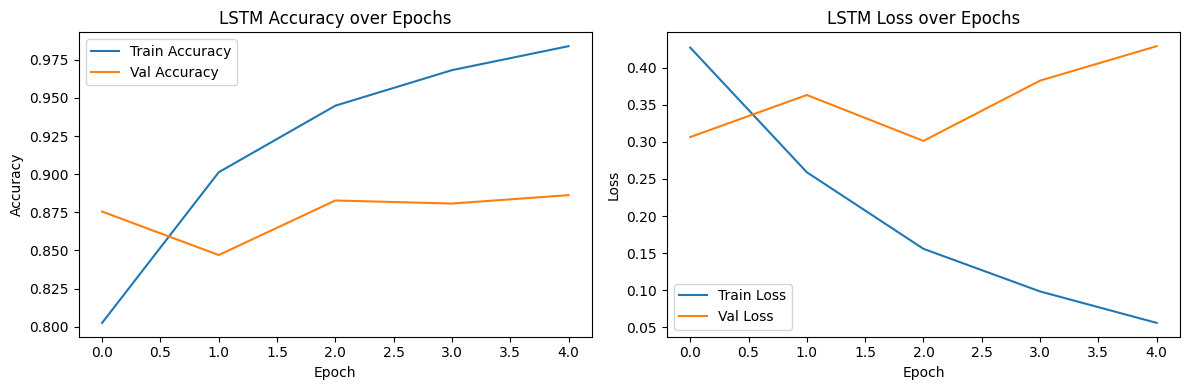

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# =============================================
# 🟠 PART B — FINE-TUNED DISTILBERT
# =============================================

#  Step 10: Tokenize with DistilBERT Tokenizer

In [ ]:
MODEL_NAME     = 'distilbert-base-uncased'
TRAIN_SIZE     = 10000
EVAL_SIZE      = 1000

bert_tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

ft_train_texts  = X_train[:TRAIN_SIZE]
ft_train_labels = y_train[:TRAIN_SIZE].tolist()
ft_test_texts   = X_test[:EVAL_SIZE]
ft_test_labels  = y_test[:EVAL_SIZE].tolist()

def tokenize(texts):
    return bert_tokenizer(
        texts,
        padding        = True,
        truncation     = True,
        max_length     = 256,
        return_tensors = 'pt'
    )

print('Tokenizing training data...')
train_encodings = tokenize(ft_train_texts)
print('Tokenizing eval data...')
test_encodings  = tokenize(ft_test_texts)
print('Done!')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing training data...
Tokenizing eval data...
Done!


#  Step 11: Create PyTorch Dataset & DataLoader

In [ ]:
class IMDBDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels    = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

train_dataset = IMDBDataset(train_encodings, ft_train_labels)
test_dataset  = IMDBDataset(test_encodings,  ft_test_labels)

train_loader  = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader   = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Test  batches: {len(test_loader)}')

Train batches: 625
Test  batches: 63


#  Step 12: Load DistilBERT Model

In [ ]:
bert_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2
)
bert_model.to(device)
print(f'Model loaded on {device}')

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on cuda


#  Step 13: Optimizer & Scheduler

In [ ]:
EPOCHS      = 3
optimizer   = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_scheduler(
    'linear',
    optimizer          = optimizer,
    num_warmup_steps   = int(0.1 * total_steps),
    num_training_steps = total_steps
)
print(f'Total steps: {total_steps}')

Total steps: 1875


#  Step 14: Fine-Tune DistilBERT (3 Epochs)

In [ ]:
train_losses   = []
val_accuracies = []

for epoch in range(EPOCHS):
    bert_model.train()
    total_loss = 0

    loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]')
    for batch in loop:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    bert_model.eval()
    all_preds, all_labels_list = [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Eval]'):
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels_list.extend(labels.cpu().numpy())

    epoch_acc = accuracy_score(all_labels_list, all_preds)
    val_accuracies.append(epoch_acc)
    print(f'\nEpoch {epoch+1} | Loss: {avg_loss:.4f} | Val Accuracy: {epoch_acc:.4f}\n')

print('✅ Fine-tuning complete!')

Epoch 1/3 [Eval]: 100%|██████████| 63/63 [00:07<00:00,  8.90it/s]



Epoch 1 | Loss: 0.3709 | Val Accuracy: 0.8980



Epoch 2/3 [Eval]: 100%|██████████| 63/63 [00:07<00:00,  8.97it/s]



Epoch 2 | Loss: 0.1987 | Val Accuracy: 0.9090



Epoch 3/3 [Eval]: 100%|██████████| 63/63 [00:07<00:00,  8.93it/s]


Epoch 3 | Loss: 0.1155 | Val Accuracy: 0.9050

✅ Fine-tuning complete!


#  Step 15: Plot DistilBERT Training Results

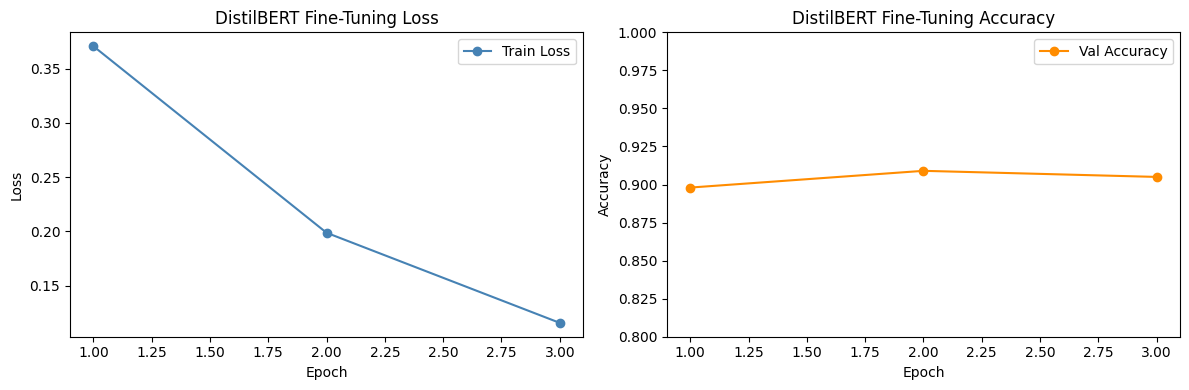

In [ ]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, marker='o', color='steelblue', label='Train Loss')
plt.title('DistilBERT Fine-Tuning Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, marker='o', color='darkorange', label='Val Accuracy')
plt.title('DistilBERT Fine-Tuning Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)
plt.legend()

plt.tight_layout()
plt.show()

# =============================================
# 🏆 PART C — FINAL COMPARISON
# =============================================

#  Step 16: Fair Comparison — Same 1000 Samples

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
LSTM Accuracy (1k samples)          : 0.8880
Fine-Tuned DistilBERT Accuracy (1k) : 0.9090


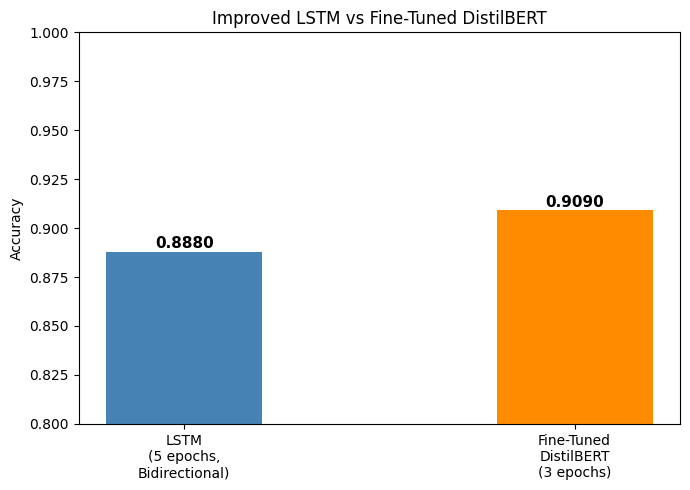

In [ ]:
# LSTM on same 1000 samples
lstm_preds_small = (lstm_model.predict(X_test_pad[:EVAL_SIZE]) > 0.5).astype(int).flatten()
lstm_acc_small   = accuracy_score(y_test[:EVAL_SIZE], lstm_preds_small)

best_transformer_acc = max(val_accuracies)

print(f'LSTM Accuracy (1k samples)          : {lstm_acc_small:.4f}')
print(f'Fine-Tuned DistilBERT Accuracy (1k) : {best_transformer_acc:.4f}')

# Bar chart
models   = ['LSTM\n(5 epochs,\nBidirectional)', 'Fine-Tuned\nDistilBERT\n(3 epochs)']
accuracy = [lstm_acc_small, best_transformer_acc]
colors   = ['steelblue', 'darkorange']

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accuracy, color=colors, width=0.4)
plt.title('Improved LSTM vs Fine-Tuned DistilBERT')
plt.ylabel('Accuracy')
plt.ylim(0.8, 1.0)

for bar, acc in zip(bars, accuracy):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{acc:.4f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

#  Step 17: Test on Custom Reviews

In [ ]:
test_reviews = [
    "This movie was fantastic and thrilling!",
    "Absolutely terrible. Waste of time.",
    "One of the best films I have ever seen!"
]

print('=' * 55)
print(f'{"Review":<35} {"LSTM":<12} {"DistilBERT"}')
print('=' * 55)

bert_model.eval()

for review in test_reviews:
    # LSTM prediction
    seq       = lstm_tokenizer.texts_to_sequences([review])
    pad       = pad_sequences(seq, maxlen=MAXLEN)
    lstm_prob = lstm_model.predict(pad, verbose=0)[0][0]
    lstm_label = 'Positive ✅' if lstm_prob > 0.5 else 'Negative ❌'

    # DistilBERT prediction
    inputs = bert_tokenizer(
        review,
        return_tensors = 'pt',
        truncation     = True,
        max_length     = 256
    ).to(device)

    with torch.no_grad():
        outputs    = bert_model(**inputs)
        probs      = torch.softmax(outputs.logits, dim=1)
        pred_label = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_label].item()

    bert_label = f'Positive ✅' if pred_label == 1 else f'Negative ❌'

    short_review = review[:32] + '...' if len(review) > 32 else review
    print(f'{short_review:<35} {lstm_label:<12} {bert_label}')

print('=' * 55)

Review                              LSTM         DistilBERT
This movie was fantastic and thr... Positive ✅   Positive ✅
Absolutely terrible. Waste of ti... Negative ❌   Negative ❌
One of the best films I have eve... Positive ✅   Positive ✅
